# Topographic-dominated eddies: polarity-dependent response to signed PV gradients

## Corrected hypothesis

For signed $PV=(\zeta+f)/h$, AEs are predicted to **align** with $\nabla PV$ ($\Delta\theta\to0^\circ$), whereas CEs are predicted to **oppose** it ($\Delta\theta\to180^\circ$).

The CE transition is: natural poleward tilt → departure as total signed $\nabla PV$ rotates → increasing opposition to the signed topographic gradient. The secondary AE hypothesis is that shelf proximity disrupts its otherwise aligned response. That mechanism must be tested separately rather than inferred from a broad distribution alone.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

## 1. Load data and define the topographic-dominated population

In [2]:
DOMINANCE_FACTOR = 2.0
MAX_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
ALIGNMENT_DEG = 45.0
RANDOM_TOLERANCE_FRACTION = ALIGNMENT_DEG / 180.0
SHELF_LON = 154.75

ELLIPSE_FRAC= 1.0
USE_PV_CACHE=True

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(
    df,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR, max_topo_depth_m=MAX_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'
# topographic = d[d.shallow_ocean_topographic & d.direction_valid].copy()
topographic = d[(d.topo_plan_ratio_smooth>=np.log(2))&(d.TiltDis>=MIN_TILT_km)&(d.h<=MAX_DEPTH_m)].copy()
topographic = topographic[np.isfinite(topographic.PV_grad_mag) & (topographic.PV_grad_mag > 0)]
topographic['log_PV_grad_mag'] = np.log(topographic.PV_grad_mag)
topographic['raw_signed_PV_mismatch'] = topographic.dtheta_PV_grad
topographic['preference_error'] = np.where(topographic.Cyc.eq('AE'),
    topographic.raw_signed_PV_mismatch, 180.0-topographic.raw_signed_PV_mismatch)
topographic['within_tolerance'] = topographic.preference_error <= ALIGNMENT_DEG
topographic['response_cosine'] = np.cos(np.deg2rad(topographic.raw_signed_PV_mismatch))
topographic['shelf_class'] = np.where(topographic.lon < SHELF_LON, 'On-shelf', 'Off-shelf')

display(topographic.groupby(['Cyc', 'shelf_class']).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_PV_grad=('PV_grad_mag', 'median'), median_raw_mismatch_deg=('raw_signed_PV_mismatch','median'),
    median_preference_error_deg=('preference_error','median'),
    within_tolerance_fraction=('within_tolerance','mean')
).round(3))

observations  eddies  median_PV_grad  \
Cyc shelf_class                                         
AE  Off-shelf            4557     261             0.0   
    On-shelf              763      77             0.0   
CE  Off-shelf            5251     293             0.0   
    On-shelf             2760     294             0.0   

                 median_raw_mismatch_deg  median_preference_error_deg  \
Cyc shelf_class                                                         
AE  Off-shelf                     95.980                       95.980   
    On-shelf                     109.232                      109.232   
CE  Off-shelf                    118.308                       61.692   
    On-shelf                     145.334                       34.666   

                 within_tolerance_fraction  
Cyc shelf_class                             
AE  Off-shelf                        0.238  
    On-shelf                         0.139  
CE  Off-shelf                        0.409  
    On-shelf                         0.601

In [3]:
topographic.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,w_surface,w_selected_depth_m,w_profile_n,h,f,beta,...,PV_grad_full_mag,PV_grad_full_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,dtheta_PV_grad_full,Ro,topo_plan_ratio,topo_plan_ratio_smooth,ellipse_frac,ellipse_inner_frac,ellipse_area_fraction,pv_averaging,pv_surface_method,pv_vorticity_reconstruction,planetary_strong,open_ocean_planetary,topographic_strong,shallow_ocean_topographic,signed_dtheta_PV_grad,expected_PV_theta,expected_direction_error,direction_valid,expected_match,log_PV_grad_mag,raw_signed_PV_mismatch,preference_error,within_tolerance,response_cosine,shelf_class
118,4,1493,CE,150.518728,-37.464100,92,42,244.562541,208.329230,-0.000066,-0.000021,1.734126,-0.362949,0.657316,37.677021,14.865502,1.837577,22.337952,36,1994-02-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,9.462144,220.692618,S2,-0.000050,126.288127,22,2859.392211,-0.000089,1.842881e-11,...,4.090028e-12,104.024509,118.165624,118.056728,139.307382,116.668109,0.744254,6.241499,6.241499,1.0,0.0,1.0,nonlinear,esp_gaussian,gaussian_streamfunction_laplacian,False,False,True,True,118.165624,282.526994,61.834376,True,False,-26.078934,118.165624,61.834376,False,-0.472022,On-shelf
119,4,1494,CE,150.430296,-37.456043,89,42,236.888864,206.512995,-0.000068,-0.000021,1.618557,-0.563463,0.878391,37.197425,13.298593,1.829614,22.925006,36,1994-02-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,10.315579,237.099325,S2,-0.000052,181.264793,22,2079.860571,-0.000089,1.843033e-11,...,1.253356e-11,105.253258,132.958985,132.876737,122.900675,131.846066,0.769950,6.515474,6.372428,1.0,0.0,1.0,nonlinear,esp_gaussian,gaussian_streamfunction_laplacian,False,False,True,True,132.958985,284.140340,47.041015,True,False,-24.952159,132.958985,47.041015,False,-0.681475,On-shelf
120,4,1495,CE,150.354841,-37.452925,87,42,230.474313,204.573533,-0.000075,-0.000017,1.223692,-0.591723,1.274639,36.717828,11.731684,1.674290,21.223970,36,1994-02-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,10.817320,256.620728,S2,-0.000043,151.065954,22,1498.939238,-0.000089,1.843128e-11,...,2.114956e-11,105.467518,151.975940,151.881258,103.379272,151.153210,0.847304,6.372428,6.372428,1.0,0.0,1.0,nonlinear,esp_gaussian,gaussian_streamfunction_laplacian,False,False,True,True,151.975940,284.644788,28.024060,True,True,-24.418926,151.975940,28.024060,True,-0.882750,On-shelf
449,9,1464,AE,159.673627,-33.089959,256,193,899.734099,953.943711,0.000034,0.000014,1.104753,0.130649,0.927845,69.580092,-34.333570,1.169424,46.987548,65,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,14.096464,99.087782,D2,0.000029,105.615538,22,2667.387262,-0.000080,1.940296e-11,...,3.044300e-13,272.033256,176.947894,175.205105,99.087782,172.945473,-0.422055,3.487336,3.466246,1.0,0.0,1.0,nonlinear,esp_gaussian,gaussian_streamfunction_laplacian,False,False,True,True,-176.947894,276.035676,176.947894,True,False,-28.991661,176.947894,176.947894,False,-0.998582,Off-shelf
450,9,1465,AE,159.688237,-33.109608,257,193,901.623234,952.329053,0.000034,0.000016,1.051871,0.150987,0.979315,69.182816,-37.989613,1.166617,47.513203,65,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,18.011224,78.116071,D2,0.000032,48.897638,22,2631.685169,-0.000080,1.939792e-11,...,3.025693e-13,270.671740,163.708441,165.493016,78.116071,167.444331,-0.422249,3.466246,3.466246,1.0,0.0,1.0,nonlinear,esp_gaussian,gaussian_streamfunction_laplacian,False,False,True,True,163.708441,274.407630,163.708441,True,False,-28.997960,163.708441,163.708441,False,-0.959847,Off-shelf


## 2. First verify the claimed AE–CE gradient contrast

The six-fold contrast is treated as an empirical claim to estimate, not as an input assumption. Medians are calculated per eddy before comparing polarities.

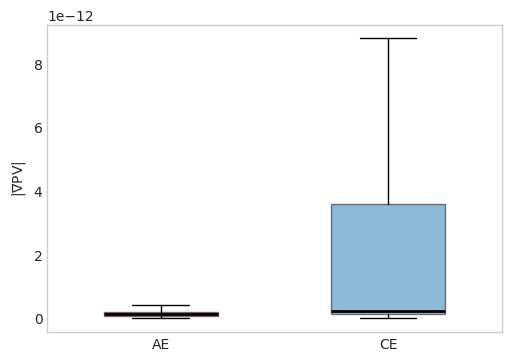

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
bp=ax.boxplot([topographic.loc[topographic.Cyc==c,'PV_grad_mag'].dropna() for c in ['AE','CE']],
              tick_labels=['AE','CE'],showfliers=False,patch_artist=True,widths=.5)
for b,c in zip(bp['boxes'],['tab:red','tab:blue']): b.set(facecolor=c,alpha=.5)
for m in bp['medians']: m.set(color='k',lw=2)
ax.set_ylabel(r'$|\nabla \mathrm{PV}|$'); ax.grid(False)

## 3. Map and alignment distributions

A common normalization is used for the AE and CE maps. Separate colour families identify polarity, but equal normalized intensity represents equal `log|∇PV|`.

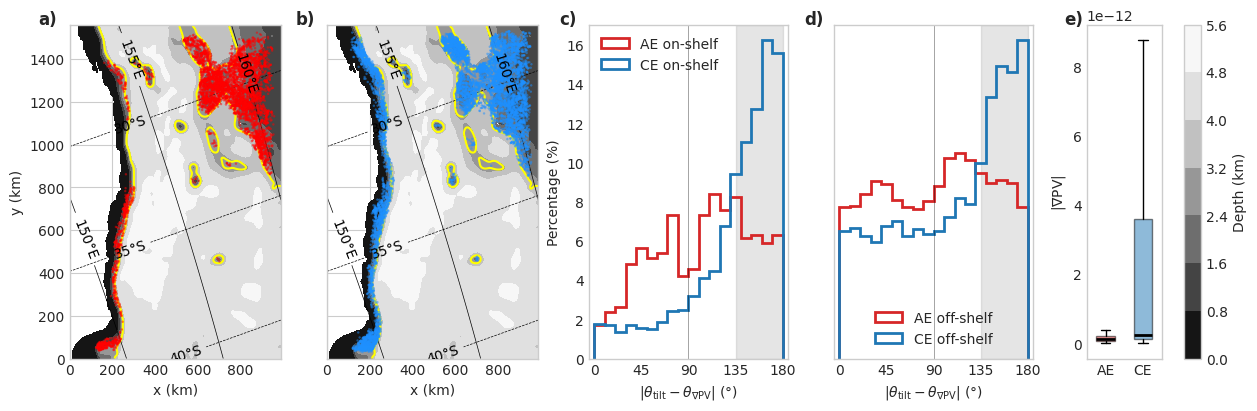

In [5]:
fig,axs=plt.subplots(1,5,figsize=(12.5,4),width_ratios=[1,1,.8,.8,.3],constrained_layout=True)

for ax,cyc in zip(axs[:2],['AE','CE']):
    d=topographic[topographic.Cyc==cyc]
    bath=ax.contourf(grid.X_grid,grid.Y_grid,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    ax.scatter(d.xc,d.yc,s=3,c='r' if cyc=='AE' else 'dodgerblue',alpha=.5,edgecolors='none',zorder=3)
    ax.contour(grid.X_grid,grid.Y_grid,grid.h,levels=[MAX_DEPTH_m],colors='yellow',zorder=2)
    tilt.lat_lon_contours(ax,grid); ax.set(xlabel='x (km)',aspect='equal')
axs[0].set_ylabel('y (km)'); axs[1].set_yticklabels([])

bins=np.arange(0,181,10)
for ax,(name,d) in zip(axs[2:4],[('on-shelf',topographic[topographic.lon<SHELF_LON]),('off-shelf',topographic[topographic.lon>SHELF_LON])]):
    for cyc,c in [('AE','tab:red'),('CE','tab:blue')]:
        x=d.loc[d.Cyc==cyc,'dtheta_PV_grad'].dropna()
        ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),histtype='step',lw=2,color=c,label=f'{cyc} {name}')
    ax.set(xlim=(-5,185),xticks=[0,45,90,135,180],xlabel=r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)')
    ax.axvspan(180-ALIGNMENT_DEG,180,color='grey',alpha=.2); ax.axvline(90,lw=.5,alpha=.5,c='k'); ax.grid(False)
    ax.legend(frameon=False,loc='upper left' if name=='on-shelf' else 'lower center')
axs[2].set_ylabel('Percentage (%)'); axs[3].set_yticklabels([])

ax=axs[4]
bp=ax.boxplot([topographic.loc[topographic.Cyc==c,'PV_grad_mag'].dropna() for c in ['AE','CE']],
              tick_labels=['AE','CE'],showfliers=False,patch_artist=True,widths=.5)
for b,c in zip(bp['boxes'],['tab:red','tab:blue']): b.set(facecolor=c,alpha=.5)
for m in bp['medians']: m.set(color='k',lw=2)
ax.set_ylabel(r'$|\nabla \mathrm{PV}|$'); ax.grid(False)

for ax,l in zip(axs,'abcde'): ax.text(-.3 if l=='e' else -.15,1,f'{l})',transform=ax.transAxes,fontweight='bold',fontsize=12)

fig.colorbar(bath,ax=axs,orientation='vertical',fraction=.025,pad=.02,label='Depth (km)')
plt.show()

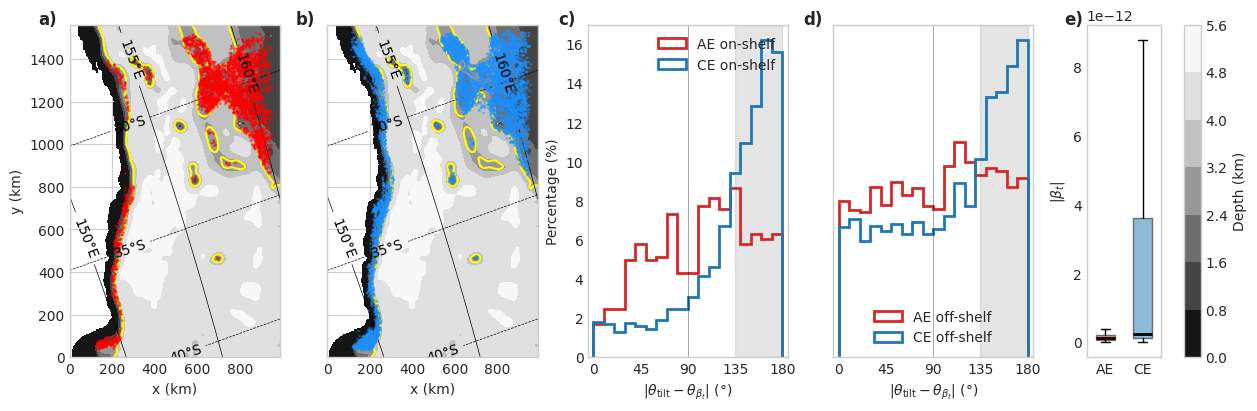

In [6]:
fig,axs=plt.subplots(1,5,figsize=(12.5,4),width_ratios=[1,1,.8,.8,.3],constrained_layout=True)

for ax,cyc in zip(axs[:2],['AE','CE']):
    d=topographic[topographic.Cyc==cyc]
    bath=ax.contourf(grid.X_grid,grid.Y_grid,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    ax.scatter(d.xc,d.yc,s=3,c='r' if cyc=='AE' else 'dodgerblue',alpha=.5,edgecolors='none',zorder=3)
    ax.contour(grid.X_grid,grid.Y_grid,grid.h,levels=[MAX_DEPTH_m],colors='yellow',zorder=2)
    tilt.lat_lon_contours(ax,grid); ax.set(xlabel='x (km)',aspect='equal')
axs[0].set_ylabel('y (km)'); axs[1].set_yticklabels([])

bins=np.arange(0,181,10)
for ax,(name,d) in zip(axs[2:4],[('on-shelf',topographic[topographic.lon<SHELF_LON]),('off-shelf',topographic[topographic.lon>SHELF_LON])]):
    for cyc,c in [('AE','tab:red'),('CE','tab:blue')]:
        x=d.loc[d.Cyc==cyc,'dtheta_PV_grad_topo'].dropna()
        ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),histtype='step',lw=2,color=c,label=f'{cyc} {name}')
    ax.set(xlim=(-5,185),xticks=[0,45,90,135,180],xlabel=r'$|\theta_{\rm tilt}-\theta_{\beta_t}|$ (°)')
    ax.axvspan(180-ALIGNMENT_DEG,180,color='grey',alpha=.2); ax.axvline(90,lw=.5,alpha=.5,c='k'); ax.grid(False)
    ax.legend(frameon=False,loc='upper right' if name=='on-shelf' else 'lower center')
axs[2].set_ylabel('Percentage (%)'); axs[3].set_yticklabels([])

ax=axs[4]
bp=ax.boxplot([topographic.loc[topographic.Cyc==c,'PV_grad_topo_mag'].dropna() for c in ['AE','CE']],
              tick_labels=['AE','CE'],showfliers=False,patch_artist=True,widths=.5)
for b,c in zip(bp['boxes'],['tab:red','tab:blue']): b.set(facecolor=c,alpha=.5)
for m in bp['medians']: m.set(color='k',lw=2)
ax.set_ylabel(r'$|\beta_t|$'); ax.grid(False)

for ax,l in zip(axs,'abcde'): ax.text(-.3 if l=='e' else -.15,1,f'{l})',transform=ax.transAxes,fontweight='bold',fontsize=12)

fig.colorbar(bath,ax=axs,orientation='vertical',fraction=.025,pad=.02,label='Depth (km)')
plt.show()

on-shelf


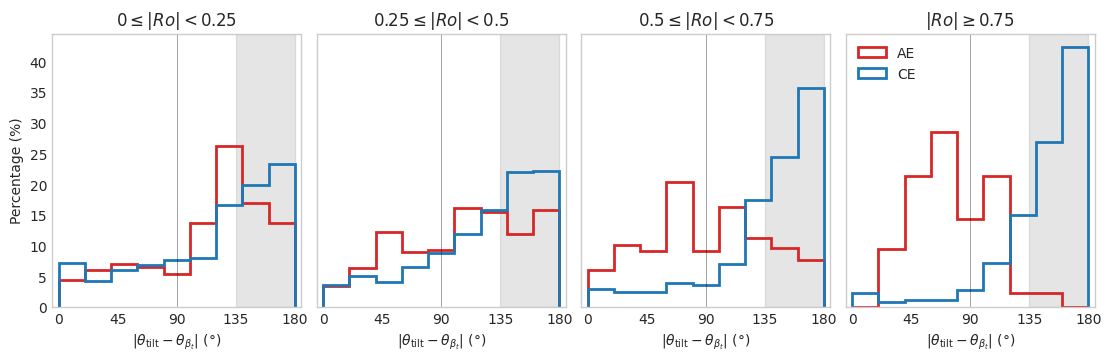

off-shelf


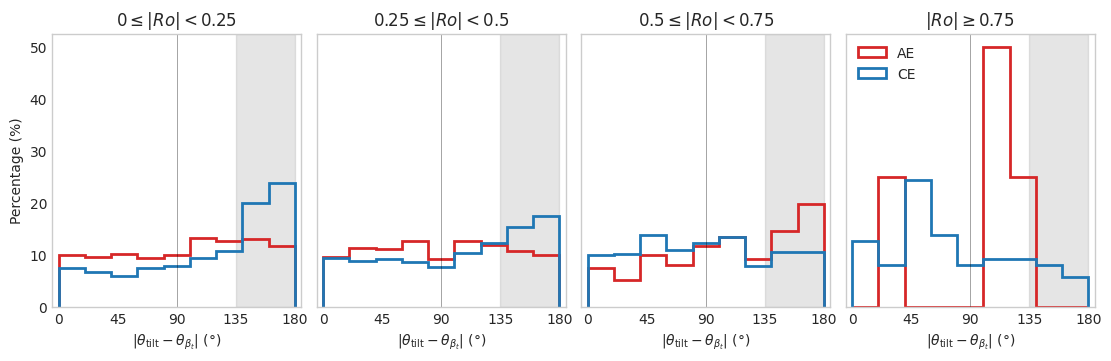

In [7]:
for title, df_d in [
    ('on-shelf', topographic[topographic.lon <= SHELF_LON].copy()),
    ('off-shelf', topographic[topographic.lon > SHELF_LON].copy())
]:
    print(title)
    df_d['Ro_abs'] = df_d.Ro.abs()
    
    bins = np.arange(0,181,20)
    ro_bins = [(0,.25),(.25,.5),(.5,.75),(.75,np.inf)]
    fig, axs = plt.subplots(1,4,figsize=(11,3.5),sharey=True,constrained_layout=True)
    
    for ax,(lo,hi) in zip(axs,ro_bins):
        d = df_d[(df_d.Ro_abs>=lo) & (df_d.Ro_abs<hi)]
        for cyc,c in [('AE','tab:red'),('CE','tab:blue')]:
            x = d.loc[d.Cyc.eq(cyc),'dtheta_PV_grad_topo'].dropna()
            ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),histtype='step',lw=2,color=c,label=cyc)
        ax.set(xlim=(-5,185),xticks=[0,45,90,135,180],
               xlabel=r'$|\theta_{\rm tilt}-\theta_{\beta_t}|$ (°)',
               title=fr'${lo:g}\leq |Ro|<{hi:g}$' if np.isfinite(hi) else r'$|Ro|\geq0.75$')
        ax.axvspan(180-ALIGNMENT_DEG,180,color='grey',alpha=.2)
        ax.axvline(90,lw=.5,alpha=.5,c='k'); ax.grid(False)
    
    axs[0].set_ylabel('Percentage (%)')
    axs[-1].legend(frameon=False)
    plt.show()

on-shelf


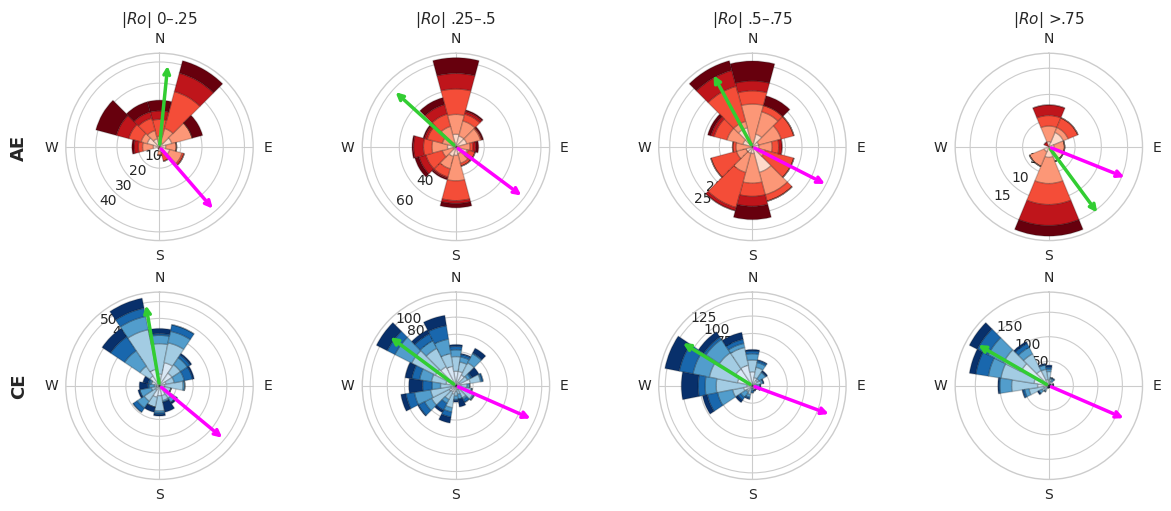

off-shelf


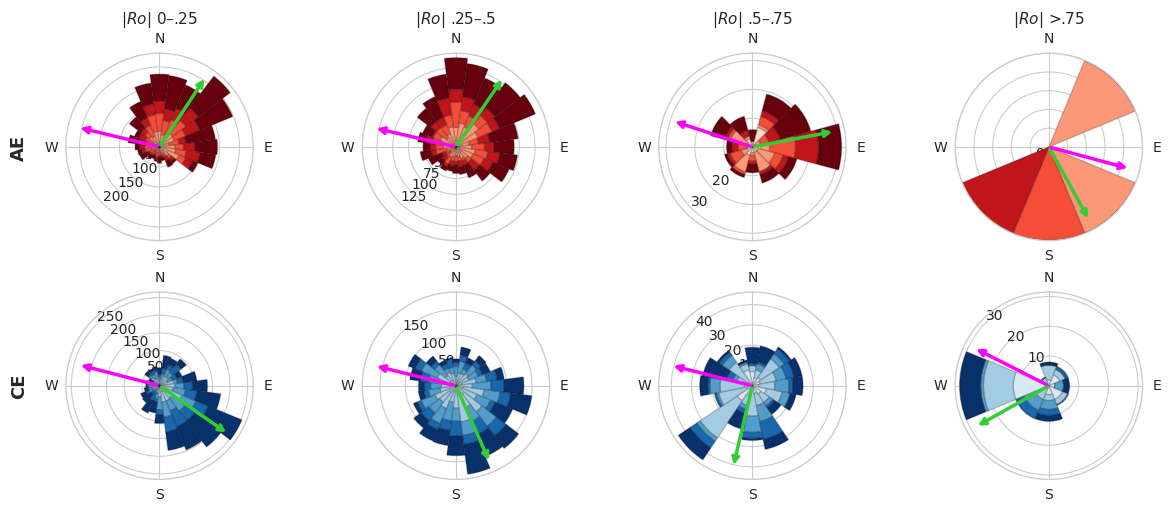

In [8]:
for title, mask in [
    ('on-shelf', topographic.lon <= SHELF_LON),
    ('off-shelf', topographic.lon > SHELF_LON)
]:
    print(title)
    ro_bins = [0,.25,.5,.75,np.inf]
    labels = ['0–.25','.25–.5','.5–.75','>.75']
    mag_bins = (0,10,20,30,40,np.inf)
    
    fig, axs = plt.subplots(2,4,figsize=(12,5),subplot_kw={'projection':'polar'},constrained_layout=True)
    
    for i,cyc in enumerate(['AE','CE']):
        for j,(lo,hi,label) in enumerate(zip(ro_bins[:-1],ro_bins[1:],labels)):
            ax = axs[i,j]
            d = topographic[(topographic.Cyc.eq(cyc)) & mask &
                            (topographic.Ro.abs()>=lo) & (topographic.Ro.abs()<hi) &
                            (topographic.TiltDis>=5)].dropna(subset=['TiltDir','TiltDis']).copy()
    
            tilt.plot_windrose(ax,d,mag_bins=mag_bins,mag='TiltDis',theta='TiltDir')
            rmax = ax.get_ylim()[1]
    
            # mean tilt direction
            theta = np.deg2rad(d.TiltDir)
            mean_theta = np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi)
            ax.annotate('',xy=(mean_theta,.9*rmax),xytext=(mean_theta,0),
                        arrowprops=dict(arrowstyle='->',color='limegreen',lw=2.5,zorder=10))
    
            # mean topographic PV-gradient vector
            topo = d.dropna(subset=['PV_grad_topo_x','PV_grad_topo_y'])
            topo_theta = np.arctan2(topo.PV_grad_topo_x.mean(),topo.PV_grad_topo_y.mean())%(2*np.pi)
            ax.annotate('',xy=(topo_theta,.9*rmax),xytext=(topo_theta,0),
                        arrowprops=dict(arrowstyle='->',color='magenta',lw=2.5,zorder=10))
    
            ax.set_title(fr'$|Ro|$ {label}' if i==0 else '',fontsize=11)
            ax.set_xticks(np.deg2rad([0,90,180,270])); ax.set_xticklabels(['N','E','S','W'])
            if j==0: ax.text(-.25,.5,cyc,transform=ax.transAxes,rotation=90,ha='center',va='center',fontsize=13,fontweight='bold')
    
    plt.show()

## 4. Primary test: conditional polarity response versus PV-gradient magnitude

Equal-population bins show both the median angular mismatch and the probability of the polarity-predicted response. A forcing threshold would appear as a relatively abrupt decline in angle and rise in alignment probability, especially for AEs. A smooth trend would instead support progressive constraint without a sharp threshold.

(array([116.,  30.,  39.,  37.,  27.,  50.,  35.,  33.,  37., 182.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, -0. ]),
 <BarContainer object of 10 artists>)

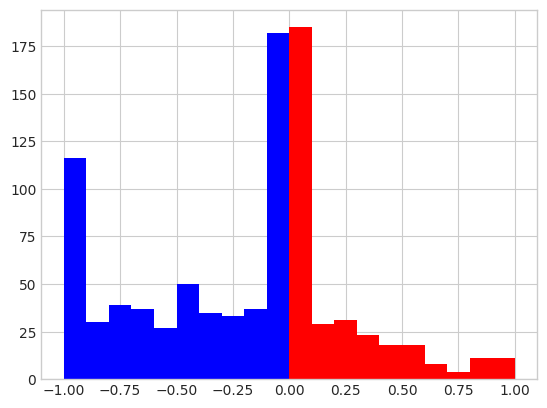

In [9]:
frac_ae = (topographic[topographic.Cyc.eq('AE')].groupby('Eddy').dtheta_PV_grad
           .apply(lambda x: (x.dropna() < 45).mean()))

frac_ce = (topographic[topographic.Cyc.eq('CE')].groupby('Eddy').dtheta_PV_grad
           .apply(lambda x: (x.dropna() > 135).mean()))

plt.hist(frac_ae, color='r')
plt.hist(-frac_ce, color='b')

## 5. Does tilt magnitude change the result?

The 5 km cutoff removes the least meaningful bearings. This sensitivity plot repeats the relationship for progressively larger tilt displacements; a physical alignment signal should not be created solely by the cutoff.

In [10]:
# fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex='col', sharey=True, constrained_layout=True)
# for j, min_tilt in enumerate([5, 10, 20]):
#     for i, (cyc, color) in enumerate([('AE', 'tab:red'), ('CE', 'tab:blue')]):
#         part = topographic[(topographic.Cyc == cyc) & (topographic.TiltDis >= min_tilt)]
#         stats = tilt.binned_alignment(part, n_bins=10)
#         axs[i, j].plot(stats.logPV, 100 * stats.p_aligned, '-o', color=color)
#         axs[i, j].axhline(100 * RANDOM_TOLERANCE_FRACTION, color='0.5', ls=':', lw=.8)
#         axs[i, j].set(title=f'{cyc}: TiltDis ≥ {min_tilt} km', ylim=(0, 100))
#         if i == 1: axs[i, j].set_xlabel(r'$\log |\nabla \mathrm{PV}|$')
#         if j == 0: axs[i, j].set_ylabel('Polarity-predicted observations (%)')

## 6. Eddy-level trend estimates

Estimate one slope per eddy where enough gradient variation exists. The distribution of slopes asks whether the relationship recurs across eddies rather than being driven by a few long tracks. Negative preference-error slopes and positive predicted-response slopes support the hypothesis.

In [11]:
# cant complete full eddy analysis becaue eddies come in and out of topographic domination

# slope_rows = []
# for (cyc, eddy), part in topographic.groupby(['Cyc', 'Eddy']):
#     if len(part) < 10 or part.log_PV_grad_mag.nunique() < 4:
#         continue
#     angle_slope = np.polyfit(part.log_PV_grad_mag, part.preference_error, 1)[0]
#     aligned_slope = np.polyfit(part.log_PV_grad_mag, part.within_tolerance.astype(float), 1)[0]
#     slope_rows.append({'Cyc': cyc, 'Eddy': eddy, 'n': len(part),
#                        'angle_slope_deg_per_logPV': angle_slope,
#                        'response_slope_per_logPV': aligned_slope})
# slopes = pd.DataFrame(slope_rows)
# display(slopes.groupby('Cyc').agg(
#     eddies=('Eddy', 'size'), median_angle_slope=('angle_slope_deg_per_logPV', 'median'),
#     fraction_negative_angle=('angle_slope_deg_per_logPV', lambda x: (x < 0).mean()),
#     median_alignment_slope=('response_slope_per_logPV', 'median'),
#     fraction_positive_alignment=('response_slope_per_logPV', lambda x: (x > 0).mean())
# ).round(3))

## 7. Interpretation and next statistical model

A convincing result requires agreement among: (1) binned angle distributions, (2) alignment probability, (3) tilt-distance sensitivity, and (4) within-eddy slopes. A formal follow-up should use a mixed-effects or clustered model with eddy as the grouping unit, allow nonlinear dependence on `log|∇PV|`, and test a polarity-by-gradient interaction. A segmented model should only be used to claim a threshold if it materially improves out-of-sample fit over a smooth monotonic alternative.